In [1]:
from nuscenes.eval.detection.config import config_factory
from nuscenes.eval.detection.evaluate import DetectionEval
from mmdet3d.unibev_plugin.datasets import DetectionEvalVis
from nuscenes.utils.splits import val, mini_val, train
from nuscenes.nuscenes import NuScenes
import numpy as np
import matplotlib.pyplot as plt
import os
import torch
import einops

In [2]:
data_root = '/home/mingdayang/mmdetection3d/data/nuscenes/'
nusc = NuScenes(version='v1.0-trainval', dataroot=data_root, verbose=True)
eval_set = 'train'
eval_detect_configs = config_factory('detection_cvpr_2019')

def find_sample_token(lidar_folder):
    print(lidar_folder.split('__'))
    timestamp_str = lidar_folder.split('__')[-1]
    print(timestamp_str)
    target_timestamp = int(timestamp_str)
    print(target_timestamp)

    # Initialize variables to track the closest sample
    closest_sample_token = None
    closest_time_diff = float('inf')

    # Iterate through all scenes
    for scene in nusc.scene:
        # Start from the first sample of the scene
        current_sample_token = scene['first_sample_token']

        while current_sample_token:
            # Retrieve the sample
            sample = nusc.get('sample', current_sample_token)

            # Calculate the time difference between the sample and the target timestamp
            time_diff = abs(sample['timestamp'] - target_timestamp)

            # Check for an exact match
            if sample['timestamp'] == target_timestamp:
                closest_sample_token = current_sample_token
                closest_time_diff = 0
                break

            # Update closest sample if this sample is closer
            if time_diff < closest_time_diff:
                closest_sample_token = current_sample_token
                closest_time_diff = time_diff

            # Move to the next sample in the scene
            current_sample_token = sample['next']

        # Break if we found an exact match
        if closest_time_diff == 0:
            break

    # Output the closest sample token and time difference
    if closest_sample_token:
        print(f"Closest sample token: {closest_sample_token}")
        print(f"Time difference (microseconds): {closest_time_diff}")
    else:
        print("No matching sample token found.")

    sample_token=closest_sample_token
    return sample_token

Loading NuScenes tables for version v1.0-trainval...
23 category,
8 attribute,
4 visibility,
64386 instance,
12 sensor,
10200 calibrated_sensor,
2631083 ego_pose,
68 log,
850 scene,
34149 sample,
2631083 sample_data,
1166187 sample_annotation,
4 map,
Done loading in 35.666 seconds.
Reverse indexing ...
Done reverse indexing in 9.8 seconds.


In [3]:
def build_paths(path):
    results_file = f'{path}/pts_bbox/results_nusc.json'
    results_dir = f'{path}/pts_bbox/'
    return results_file, results_dir

In [4]:
# path = '/home/mingdayang/mmdetection3d/outputs/inference/baseline/unibev_C_full_nuscenes/'
path = '/home/mingdayang/mmdetection3d/outputs/inference/camera_pseudo_experiment/20-04-2026-1_unibev_val_C_full_nuscenes_train_inference'
results_C, results_dir_C = build_paths(path)

nusc_C = DetectionEvalVis(
    nusc = nusc,
    config=eval_detect_configs,
    result_path=results_C,
    eval_set=eval_set,
    output_dir=results_dir_C,
    verbose=True)

Initializing nuScenes detection evaluation
Loaded results from /home/mingdayang/mmdetection3d/outputs/inference/camera_pseudo_experiment/20-04-2026-1_unibev_val_C_full_nuscenes_train_inference/pts_bbox/results_nusc.json. Found detections for 28130 samples.
Loading annotations for train split from nuScenes version: v1.0-trainval


100%|██████████| 28130/28130 [00:56<00:00, 499.07it/s] 


Loaded ground truth annotations for 28130 samples.
Filtering predictions
=> Original number of boxes: 6228561
=> After distance based filtering: 6227141
=> After LIDAR and RADAR points based filtering: 6227141
=> After bike rack filtering: 6224800
Filtering ground truth annotations
=> Original number of boxes: 944881
=> After distance based filtering: 691869
=> After LIDAR and RADAR points based filtering: 624040
=> After bike rack filtering: 624040


In [5]:
val_scene_names = set(val)
all_val_sample_tokens = []

for scene in nusc.scene:
    if scene['name'] not in val_scene_names:
        continue

    current_sample_token = scene['first_sample_token']
    while current_sample_token:
        all_val_sample_tokens.append(current_sample_token)
        current_sample = nusc.get('sample', current_sample_token)
        current_sample_token = current_sample['next']

all_val_sample_tokens = np.array(all_val_sample_tokens, dtype=object)
print(f'Total validation sample tokens: {len(all_val_sample_tokens)}')
print('First 5 tokens:', all_val_sample_tokens[:5])

Total validation sample tokens: 6019
First 5 tokens: ['fd8420396768425eabec9bdddf7e64b6' '6eb8a3ff0abf4f3a9380a48f2a0b87ef'
 'b10f0cd792b64d16a1a5e8349b20504c' '163b70e627854893b88575caf85a56ea'
 'f56a544064a548a39a81f18cc8f633c5']


In [6]:
train_scene_names = set(train)
all_train_sample_tokens = []

for scene in nusc.scene:
    if scene['name'] not in train_scene_names:
        continue

    current_sample_token = scene['first_sample_token']
    while current_sample_token:
        all_train_sample_tokens.append(current_sample_token)
        current_sample = nusc.get('sample', current_sample_token)
        current_sample_token = current_sample['next']

all_train_sample_tokens = np.array(all_train_sample_tokens, dtype=object)
print(f'Total training sample tokens: {len(all_train_sample_tokens)}')
print('First 5 tokens:', all_train_sample_tokens[:5])

Total training sample tokens: 28130
First 5 tokens: ['e93e98b63d3b40209056d129dc53ceee' '14d5adfe50bb4445bc3aa5fe607691a8'
 'ae4e0c3aa3f24c91aab599e8b54e9264' '8de7ec06e1ac48c689c4d24d6cc64fd7'
 'ba94cb79ebc74614bc2442185cb53c26']


Using from_file to load point cloud


/home/mingdayang/mmdetection3d/mmdet3d/unibev_plugin/datasets/detection_eval_custom.py:329: UserWarning: You have mixed positional and keyword arguments, some input may be discarded.
  handles=[mpatches.Patch(color='b'), mpatches.Patch(color='g'), mpatches.Patch(color='r')])


Rendering sample token f9c2a1179d744a8eba8456ed87239237


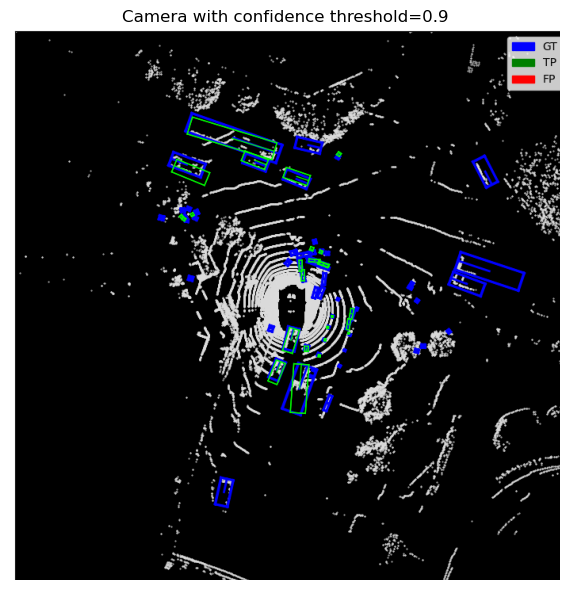

In [9]:
from random import sample
def figure_to_image(fig):
    fig.canvas.draw()  # Render the figure
    # Convert to a numpy array
    image = np.frombuffer(fig.canvas.tostring_rgb(), dtype='uint8')
    image = image.reshape(fig.canvas.get_width_height()[::-1] + (3,))
    plt.close(fig)  # Close the figure after conversion
    return image
plt.rcdefaults()
def plot_singular_BEV_pointcloud(sample_token, nusc, vis_num_beams=8, nsweeps=3, conf_th=0.15):
    """Plots the BEV point cloud for a given sample token.
    Blue: Ground truth
    Green: True Positive
    Red: False Positive
    """
    
    fig, ax = plt.subplots(1, 1, figsize=(6,6))

    sensor_dict = {"visualize_num_beams": vis_num_beams, "num_beam_sensor": 32, "nsweeps": nsweeps}
    sample_fig = nusc.main_vis_per_sample(
        sample_token,
        conf_th=conf_th,
        with_GT=True,
        display_legend=True,
        sensor_dict=sensor_dict
    )
    sample_image = figure_to_image(sample_fig)
    ax.imshow(sample_image)
    # ax.set_title(f"BEV Point Cloud for Sample Token: {sample_token} ({vis_num_beams} beams)")
    ax.set_title(f"Camera with confidence threshold={conf_th}")
    ax.axis('off')
    ax.set_ylim(800, 106)
    ax.set_xlim(106, 800)
    plt.tight_layout()
    plt.close(sample_fig)
    plt.show()

# sample_token = all_val_sample_tokens[0]
sample_token = all_train_sample_tokens[3500]
plot_singular_BEV_pointcloud(sample_token, nusc_C, vis_num_beams=32, nsweeps=3, conf_th=0.9)

In [8]:
from mmdet3d.unibev_plugin.datasets.detection_eval_custom import get_boxes_conf_th
from nuscenes.eval.common.utils import center_distance

def tp_fp_fn_tn_for_sample(eval_obj, sample_token, conf_th=0.4, dist_th=2.0):
    gt_boxes = eval_obj.gt_boxes[sample_token]
    pred_boxes = eval_obj.pred_boxes[sample_token] if sample_token in eval_obj.pred_boxes.sample_tokens else []

    per_class = get_boxes_conf_th(
        gt_boxes, pred_boxes, eval_obj.cfg.class_names,
        center_distance, conf_th=conf_th, dist_th=dist_th
    )

    gt_count_by_class = {class_name: 0 for class_name in eval_obj.cfg.class_names}
    for gt_box in gt_boxes:
        if gt_box.detection_name in gt_count_by_class:
            gt_count_by_class[gt_box.detection_name] += 1

    tp = 0
    fp = 0
    fn = 0
    for entry in per_class:
        class_name = entry["class_name"]
        tp_class = len(entry["tp_boxes"])
        fp_class = len(entry["fp_boxes"])
        fn_class = max(gt_count_by_class[class_name] - tp_class, 0)

        tp += tp_class
        fp += fp_class
        fn += fn_class

    # For 3D object detection, TN is not well-defined without a finite set of negative candidates.
    tn = None
    return tp, fp, fn, tn, per_class

# example: one sample
tp, fp, fn, tn, details = tp_fp_fn_tn_for_sample(nusc_C, sample_token, conf_th=0.9)
print("TP:", tp, "FP:", fp, "FN:", fn, "TN:", "N/A" if tn is None else tn)

TP: 26 FP: 0 FN: 33 TN: N/A


In [19]:
total_tp, total_fp, total_fn = 0, 0, 0
per_sample_counts = {}

for tok in all_val_sample_tokens:
    tp, fp, fn, tn, _ = tp_fp_fn_tn_for_sample(nusc_C, tok, conf_th=0.4)
    per_sample_counts[tok] = {"tp": tp, "fp": fp, "fn": fn, "tn": tn}
    total_tp += tp
    total_fp += fp
    total_fn += fn

print("Total TP:", total_tp, "Total FP:", total_fp, "Total FN:", total_fn, "Total TN: N/A")
print("Note: TN is undefined for nuScenes box matching unless you define a finite negative candidate set.")

KeyboardInterrupt: 

In [23]:
thresholds = np.arange(0.05, 1.0, 0.05)
print(thresholds)

precisions = {}
recalls = {}
F1_scores = {}

for t in thresholds:
    total_tp, total_fp, total_fn = 0, 0, 0
    # Precision = TP / (TP + FP)
    # Recall = TP / (TP + FN)
    for tok in all_train_sample_tokens:
        tp, fp, fn, tn, _ = tp_fp_fn_tn_for_sample(nusc_C, tok, conf_th=t)
        total_tp += tp
        total_fp += fp
        total_fn += fn
    
    precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0
    recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    precisions[t] = precision
    recalls[t] = recall
    F1_scores[t] = f1_score

    print(f"Threshold: {t:.2f} - Total TP: {total_tp}, Total FP: {total_fp}, Total FN: {total_fn}, Total TN: N/A")

[0.05 0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65 0.7
 0.75 0.8  0.85 0.9  0.95]
Threshold: 0.05 - Total TP: 605131, Total FP: 2124157, Total FN: 18909, Total TN: N/A
Threshold: 0.10 - Total TP: 597280, Total FP: 1022488, Total FN: 26760, Total TN: N/A
Threshold: 0.15 - Total TP: 588301, Total FP: 606324, Total FN: 35739, Total TN: N/A
Threshold: 0.20 - Total TP: 576903, Total FP: 380458, Total FN: 47137, Total TN: N/A
Threshold: 0.25 - Total TP: 562290, Total FP: 241161, Total FN: 61750, Total TN: N/A
Threshold: 0.30 - Total TP: 544196, Total FP: 152759, Total FN: 79844, Total TN: N/A
Threshold: 0.35 - Total TP: 523077, Total FP: 97894, Total FN: 100963, Total TN: N/A
Threshold: 0.40 - Total TP: 500626, Total FP: 64772, Total FN: 123414, Total TN: N/A
Threshold: 0.45 - Total TP: 479012, Total FP: 45800, Total FN: 145028, Total TN: N/A
Threshold: 0.50 - Total TP: 459114, Total FP: 34020, Total FN: 164926, Total TN: N/A
Threshold: 0.55 - Total TP: 440448, Total FP: 26370

In [24]:
print("F1 max:", max(F1_scores.values()), "at threshold:", max(F1_scores, key=F1_scores.get))
print("Precisions at 0.4:", precisions[0.4], "Recalls at 0.4:", recalls[0.4], "F1 at 0.4:", F1_scores[0.4])

F1 max: 0.8417857845469878 at threshold: 0.4
Precisions at 0.4: 0.885439990944432 Recalls at 0.4: 0.802233831164669 F1 at 0.4: 0.8417857845469878


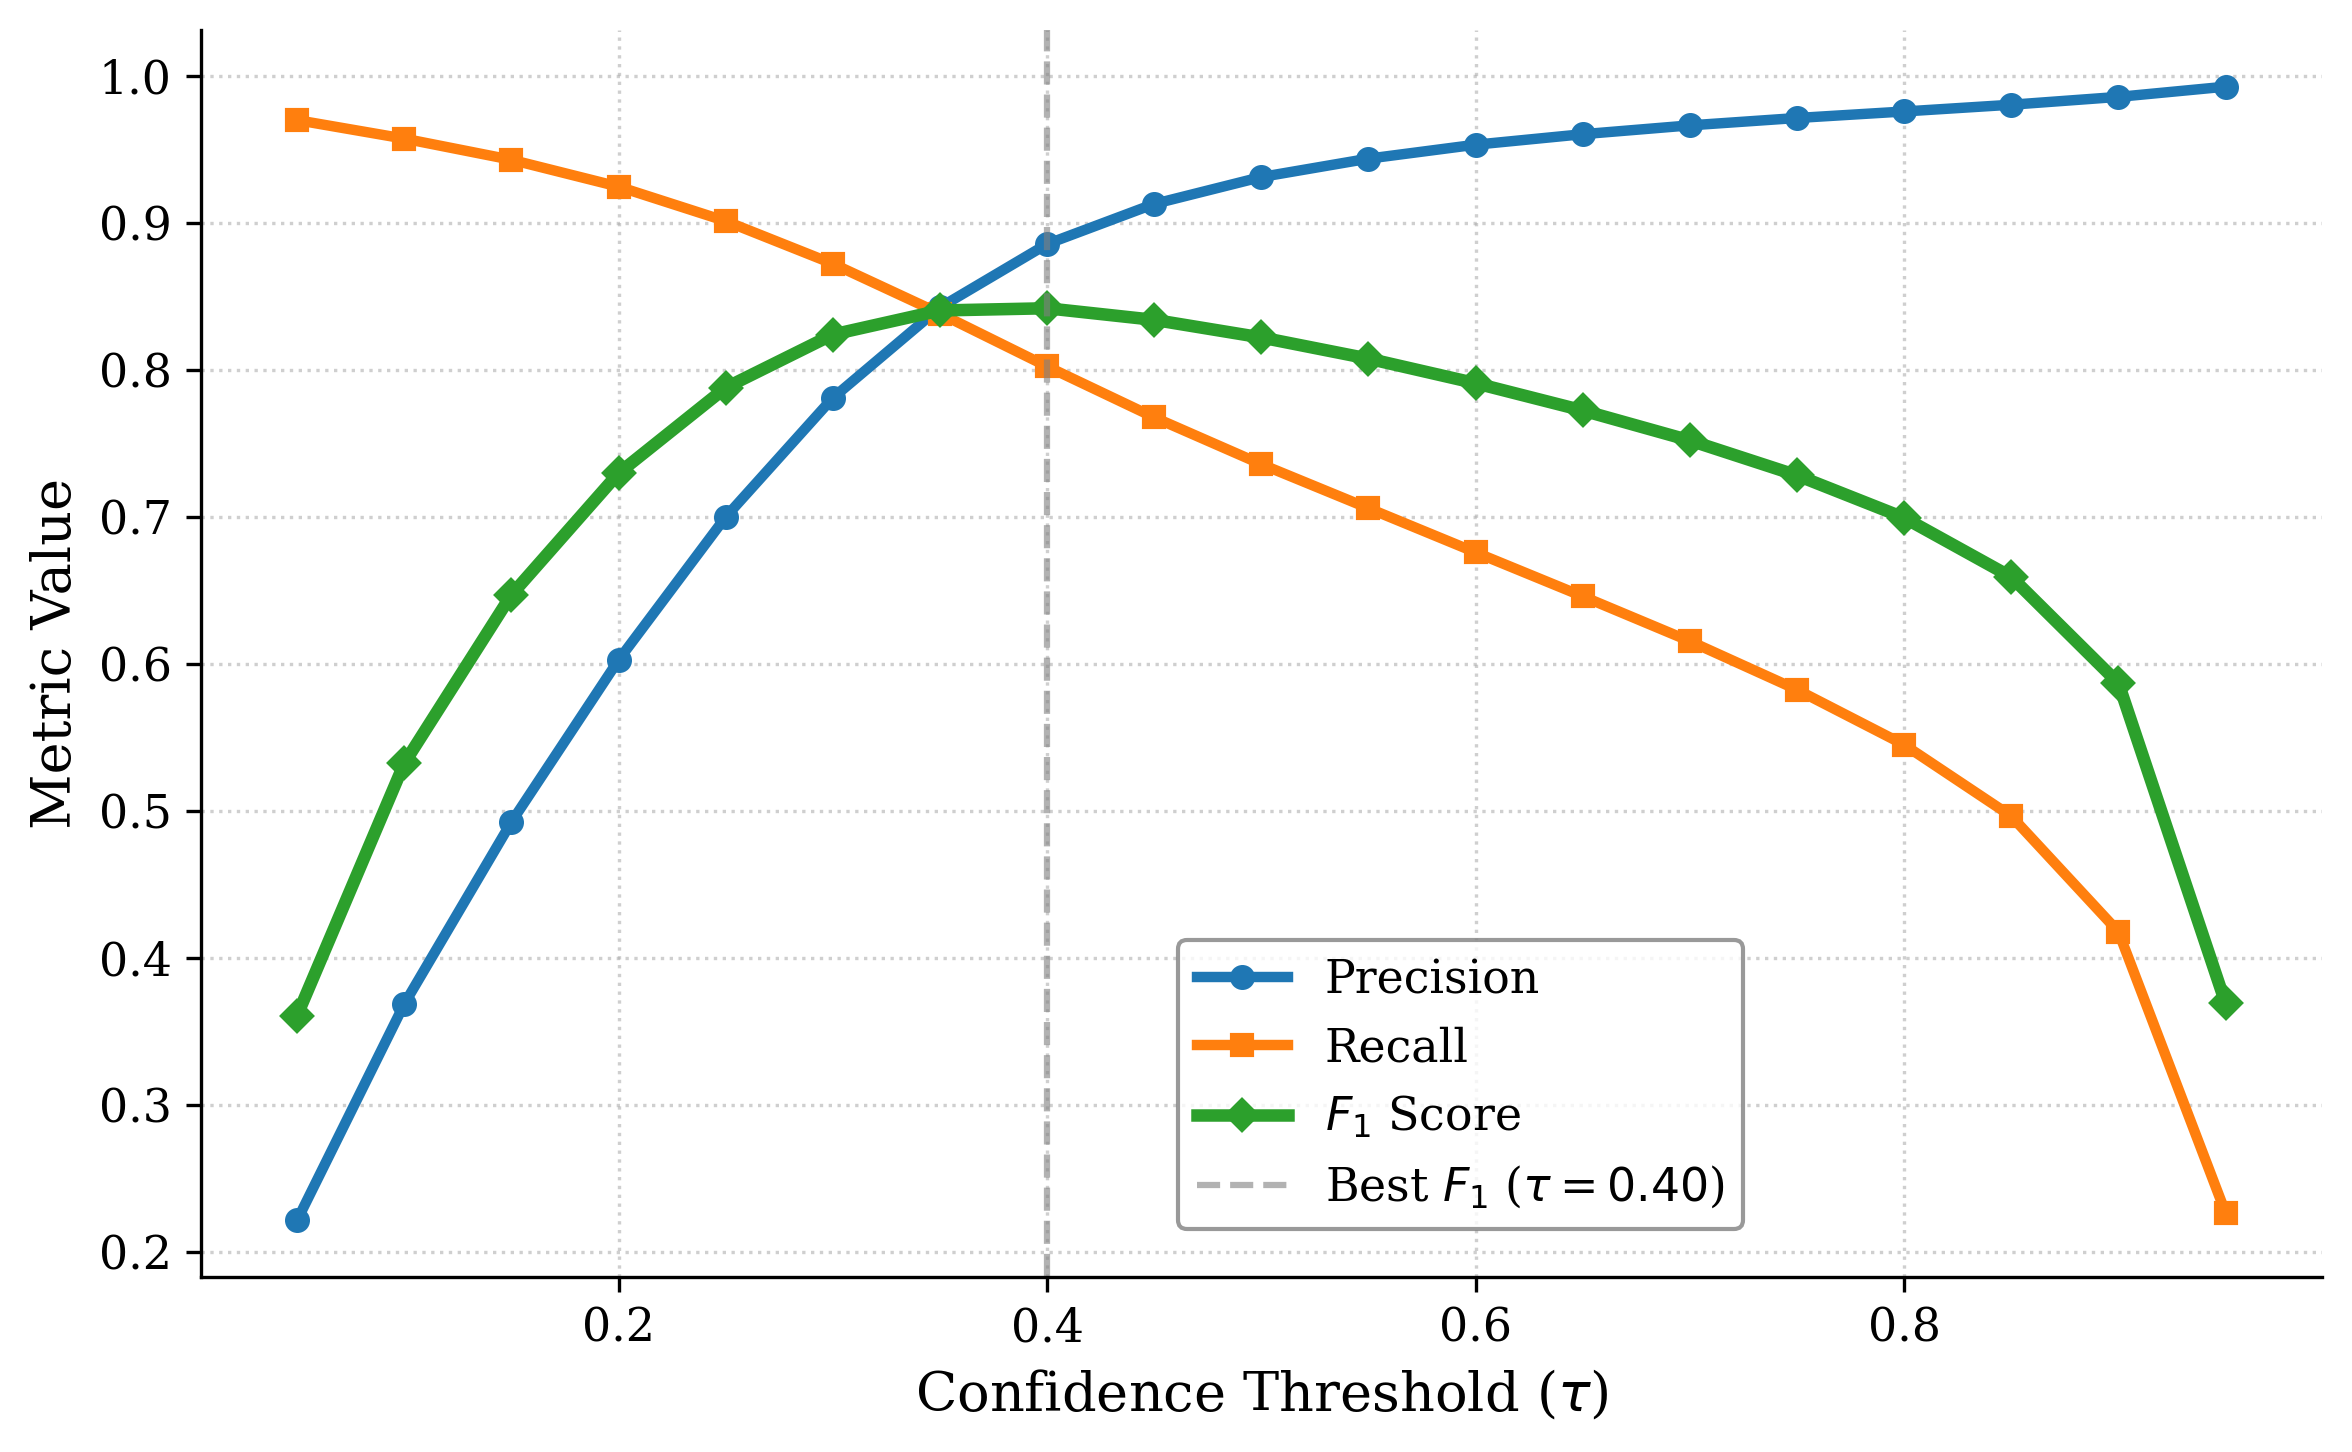

In [25]:
import matplotlib.pyplot as plt
import numpy as np

def plot_threshold_against_metrics(thresholds, precisions, recalls, F1_scores):
    # Convert dict values to lists
    p_vals = list(precisions.values())
    r_vals = list(recalls.values())
    f1_vals = list(F1_scores.values())
    
    # Identify the optimal threshold (Max F1)
    best_idx = np.argmax(f1_vals)
    best_tau = thresholds[best_idx]
    
    # 1. Academic styling: use LaTeX if available, otherwise set high-quality fonts
    plt.rcParams.update({
        "font.family": "serif",
        "font.size": 12,
        "axes.titlesize": 14,
        "axes.labelsize": 13,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "legend.fontsize": 11,
        "figure.dpi": 300  # High resolution for publication
    })

    plt.figure(figsize=(8, 5))
    
    # 2. Plot lines with academic color palette and distinct markers
    plt.plot(thresholds, p_vals, label='Precision', color='#1f77b4', 
             linewidth=2.5, marker='o', markersize=5, markevery=1)
    plt.plot(thresholds, r_vals, label='Recall', color='#ff7f0e', 
             linewidth=2.5, marker='s', markersize=5, markevery=1)
    plt.plot(thresholds, f1_vals, label='$F_1$ Score', color='#2ca02c', 
             linewidth=3, marker='D', markersize=5, markevery=1)

    # 3. Add Vertical line for the 'Optimal' Point with raw string for LaTeX
    plt.axvline(x=best_tau, color='gray', linestyle='--', alpha=0.6, 
                label=r'Best $F_1$ ($\tau = {:.2f}$)'.format(best_tau))

    # 4. Axis Labels with LaTeX math symbols
    plt.xlabel(r'Confidence Threshold ($\tau$)')
    plt.ylabel('Metric Value')
    
    # 5. Visual Cleanup: Removing chart junk
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    
    # 6. Legend Placement: 'lower left' is the cleanest empty space for this data
    # plt.legend(frameon=True, loc='lower left', fancybox=True, edgecolor='gray')
    # loc='lower left' sets which corner of the legend box the coordinates refer to
    # bbox_to_anchor=(x, y) sets the actual position
    plt.legend(
        frameon=True, 
        loc='lower left', 
        bbox_to_anchor=(0.45, 0.02), # 5% from left, 10% from bottom
        fancybox=True, 
        edgecolor='gray'
)

    plt.tight_layout()
    
    # 7. Save as PDF for infinite scalability in LaTeX papers
    plt.savefig('threshold_metrics_plot.pdf', bbox_inches='tight')
    plt.show()

# Run the function
plot_threshold_against_metrics(thresholds, precisions, recalls, F1_scores)